<a href="https://colab.research.google.com/github/Xyrfo/Pembelajaran-Mesin/blob/main/JS05/tugas_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab 1 - kNN Voice

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Load Data

In [3]:
uploaded = files.upload()
data = pd.read_csv(next(iter(uploaded)))
display(data.head())
print(data.shape, data.columns.tolist())
label_candidates = [c for c in data.columns if c.lower() in ['label','gender','jenis_kelamin']]
label_col = label_candidates[0] if label_candidates else data.columns[-1]
data = data.dropna().copy()
X = data.drop(columns=[label_col]).select_dtypes(include=np.number)
encoder = LabelEncoder()
y = encoder.fit_transform(data[label_col].astype(str))
print('Label:', label_col)
print('Distribusi label:')
print(pd.Series(encoder.inverse_transform(y)).value_counts())
print('Fitur numerik:', X.columns.tolist())

Saving voice.csv to voice.csv


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


(3168, 21) ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label']
Label: label
Distribusi label:
male      1584
female    1584
Name: count, dtype: int64
Fitur numerik: ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']


## Seleksi Fitur dan Pencarian k

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline = Pipeline([('scaler', StandardScaler()), ('selector', SelectKBest(mutual_info_classif)), ('knn', KNeighborsClassifier())])
parameter = {'selector__k': list(range(1, X.shape[1] + 1)), 'knn__n_neighbors': list(range(1, 21, 2))}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipeline, parameter, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print('Parameter terbaik:', grid.best_params_)
print('Akurasi CV terbaik:', round(grid.best_score_, 4))

Parameter terbaik: {'knn__n_neighbors': 1, 'selector__k': 12}
Akurasi CV terbaik: 0.9791


## Grafik Analisis

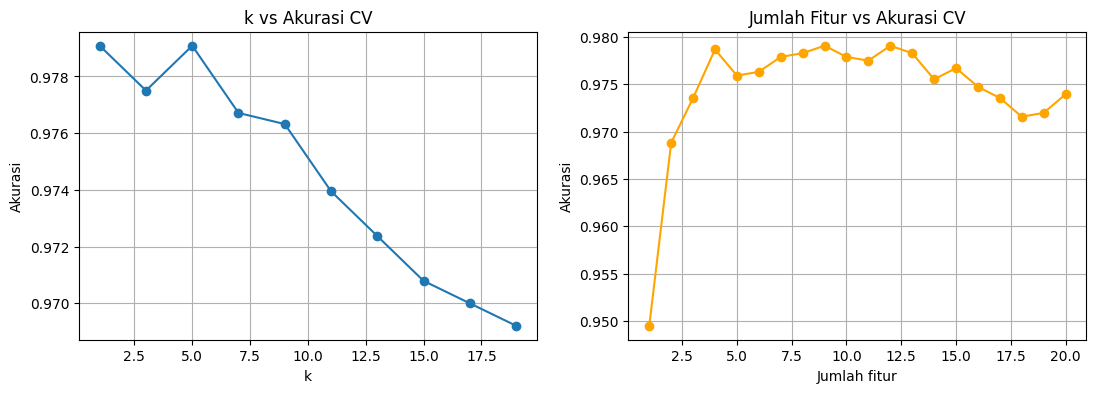

,Fitur,Skor mutual information
12,meanfun,0.555423
5,IQR,0.449226
3,Q25,0.406534
1,sd,0.302449
10,mode,0.176703
8,sp.ent,0.170858
9,sfm,0.126971
0,meanfreq,0.116538
11,centroid,0.116538
16,mindom,0.095840


Fitur terpilih: ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'mindom', 'maxdom']


In [5]:
hasil = pd.DataFrame(grid.cv_results_)
by_k = hasil.groupby('param_knn__n_neighbors')['mean_test_score'].max()
by_features = hasil.groupby('param_selector__k')['mean_test_score'].max()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(by_k.index.astype(int), by_k.values, marker='o')
ax[0].set(title='k vs Akurasi CV', xlabel='k', ylabel='Akurasi')
ax[0].grid()
ax[1].plot(by_features.index.astype(int), by_features.values, marker='o', color='orange')
ax[1].set(title='Jumlah Fitur vs Akurasi CV', xlabel='Jumlah fitur', ylabel='Akurasi')
ax[1].grid()
plt.show()
selector = grid.best_estimator_.named_steps['selector']
fitur_terpilih = X.columns[selector.get_support()].tolist()
skor_fitur = pd.DataFrame({'Fitur': X.columns, 'Skor mutual information': selector.scores_}).sort_values('Skor mutual information', ascending=False)
display(skor_fitur)
print('Fitur terpilih:', fitur_terpilih)

## Evaluasi Testing dan Kesimpulan

Akurasi testing: 0.9811
              precision    recall  f1-score   support

      female       0.98      0.98      0.98       317
        male       0.98      0.98      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



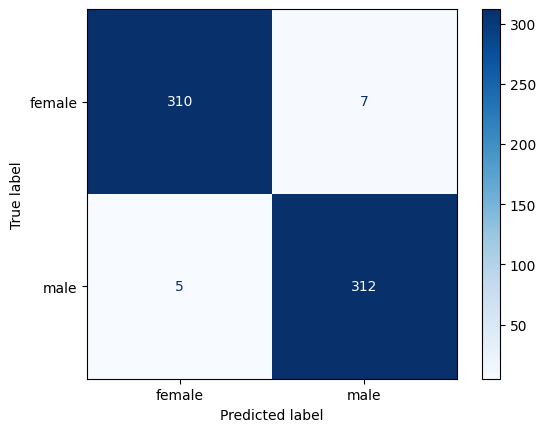

KESIMPULAN
Fitur terbaik: ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'mindom', 'maxdom']
Nilai k terbaik: 1
Akurasi validasi silang: 0.9791
Akurasi testing: 0.9811
Kombinasi dipilih karena menghasilkan akurasi validasi silang tertinggi.


In [6]:
pred = grid.predict(X_test)
akurasi = accuracy_score(y_test, pred)
print('Akurasi testing:', round(akurasi, 4))
print(classification_report(y_test, pred, target_names=encoder.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=encoder.classes_, cmap='Blues')
plt.show()
print('KESIMPULAN')
print('Fitur terbaik:', fitur_terpilih)
print('Nilai k terbaik:', grid.best_params_['knn__n_neighbors'])
print('Akurasi validasi silang:', round(grid.best_score_, 4))
print('Akurasi testing:', round(akurasi, 4))
print('Kombinasi dipilih karena menghasilkan akurasi validasi silang tertinggi.')